# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Ляшко Леся'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 9     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Ляшко Леся, ШІ-32, варіант 9
ваш потік:                   P>50
ваша пара для графіка 3:     потік E>0.8 та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
import pandas as pd

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'
df=pd.read_excel(ФАЙЛ)
print(df.head())
print(df.dtypes)

   Unnamed: 0        ftp://ftp.swpc.noaa.gov/pub/lists/particle/ Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12  \
0         NaN                                                NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
1         NaN                :Data_list: 20170901_Gs_part_5m.txt        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
2         NaN                     :Created: 2017 Sep 02 0011 UTC        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
3         NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
4         NaN  # Please send comments an

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)* Оскільки на Sheet1 розміщено три різні таблиці та певні заголовки, що не стосуються них, то звичайне читання не спрацювало відповідно, адже перший рядок не відповідає за заголовок, як би мало бути насправді

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print(RAW.shape)
print(RAW.head(30))


(7226, 32)
    0                                                  1    2    3     4         5        6      7      8      9       10      11      12     13     14  15  \
0  NaN        ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
1  NaN                                                NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
2  NaN                :Data_list: 20170901_Gs_part_5m.txt  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
3  NaN                     :Created: 2017 Sep 02 0011 UTC  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
4  NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
5  NaN  # Please send comments and 

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
print(RAW.notna().sum())


0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)* 3 таблиці: перша - B:O, друга - Q:T,третя - Y:AF.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
pd.read_excel(ФАЙЛ, header=None)
for i in range(21):
    print(i, list(RAW.iloc[i].dropna()))

0 ['ftp://ftp.swpc.noaa.gov/pub/lists/particle/', 'http://umtof.umd.edu/pm/crn/']
1 []
2 [':Data_list: 20170901_Gs_part_5m.txt', 'SOHO CELIAS Proton Monitor']
3 [':Created: 2017 Sep 02 0011 UTC', 'Solar Wind Parameters for Carrington Rotation (hour averages)']
4 ['# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center', 'Proton speed [km/sec]']
5 ['# Please send comments and suggestions to SWPC.Webmaster@noaa.gov ', 'Proton density [protons per cubic centimeter]']
6 ['# ']
7 ['# Label: P > 1 = Particles at >1 Mev', 'Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second)']
8 ['# Label: P > 5 = Particles at >5 Mev']
9 ['# Label: P >10 = Particles at >10 Mev']
10 ['# Label: P >30 = Particles at >30 Mev']
11 ['# Label: P >50 = Particles at >50 Mev']
12 ['# Label: P>100 = Particles at >100 Mev']
13 ['# Label: E>0.8 = Electrons at >0.8 Mev', 'ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt']
14 ['# Label: E>2.0 = Electrons at >

**Відповідь 1.4:**

| Таблиця | Джерело                                                                                                                      | Одиниці вимірювання                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|---------|------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| A       | ftp://ftp.swpc.noaa.gov/pub/lists/particle/  # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center | # Label: P > 5 = Particles at >5 Mev ; # Label: P > 1 = Particles at >1 Mev ; # Label: P >10 = Particles at >10 Mev; # Label: P >10 = Particles at >10 Mev; # Label: P >30 = Particles at >30 Mev; # Label: P >50 = Particles at >50 Mev; # Label: P>100 = Particles at >100 Mev ; # Label: E>0.8 = Electrons at >0.8 Mev ; # Label: E>2.0 = Electrons at >2.0 Mev ; # Label: E>4.0 = Electrons at >4.0 Mev ; # Units: Particles = Protons/cm2-s-sr ; # Units: Electrons = Electrons/cm2-s-sr; |
| B       | ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt #  Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center                                                              |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| C       | http://umtof.umd.edu/pm/crn/                                                                                                 | Proton speed [km/sec] \ Proton density [protons per cubic centimeter] \ Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second)                                                                                                                                                                                                                                                                                                                                        |

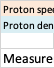
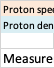
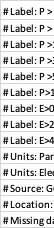

---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, sheet_name='Sheet1', header=None)
A = RAW.iloc[26:, 1:15].dropna(how='all').copy()
B = RAW.iloc[27:, 16:20].dropna(how='all').copy()
C = RAW.iloc[27:, 24:32].dropna(how='all').copy()

A.columns = [ 'year', 'month', 'day', 'hour', 'modified julian day','seconds of the day', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0' ]
B.columns = [ 'year', 'month', 'day', 'F10.7' ]
C.columns = ['hour1', 'hour2', 'year', 'month', 'day', 'hour', 'speed', 'density']

for column in A.columns:
    A[column] = pd.to_numeric(A[column], errors='coerce')
for column in B.columns:
    B[column] = pd.to_numeric(B[column], errors='coerce')
for column in C.columns:
    C[column] = pd.to_numeric(C[column], errors='coerce')

display(A.head())
display(B.head())
display(C.head())


,year,month,day,hour,modified julian day,seconds of the day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0
26,2017,8,28,0,57993,0,12.00,0.260,0.180,0.1140,0.1040,0.0793,23600.0,1180.0
27,2017,8,28,5,57993,300,19.40,0.690,0.314,0.1120,0.0612,0.0251,23100.0,1160.0
28,2017,8,28,10,57993,600,8.48,0.168,0.130,0.0717,0.0614,0.0304,22200.0,1090.0
29,2017,8,28,15,57993,900,15.40,0.566,0.198,0.0926,0.0568,0.0251,20400.0,997.0
30,2017,8,28,20,57993,1200,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500.0,875.0


,year,month,day,F10.7
27,2017,8,28,82
28,2017,8,29,84
29,2017,8,30,87
30,2017,8,31,92
31,2017,9,1,93


,hour1,hour2,year,month,day,hour,speed,density
27,0.0,0.0,17,8,28,0,285,3.0
28,1.0,1.0,17,8,28,1,305,3.4
29,2.0,2.0,17,8,28,2,309,1.7
30,3.0,3.0,17,8,28,3,304,2.0
31,4.0,4.0,17,8,28,4,302,2.3


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A['ts'] = pd.to_datetime(
    A['year'].astype(str) + '-' +
    A['month'].astype(str) + '-' +
    A['day'].astype(str) + ' ' +
    A['hour'].astype(str).str.zfill(4),
    format='%Y-%m-%d %H%M'
)

B['ts'] = pd.to_datetime(
    B[['year', 'month', 'day']]
)

C['year'] = C['year'] + 2000

C['ts'] = pd.to_datetime(
    C[['year', 'month', 'day', 'hour']]
)

print("A:", A['ts'].min(), "—", A['ts'].max())
print("B:", B['ts'].min(), "—", B['ts'].max())
print("C:", C['ts'].min(), "—", C['ts'].max())


A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
tables=[('A', A), ('B', B), ('C', C)]
for n,t in tables:
    print(n, "\n\n", t.shape, "\n", t.dtypes, "\n", t.isna().sum(), "\n", t.duplicated().sum(), "\n", t.describe(), "\n\n")

A 

 (7200, 15) 
 year                            int64
month                           int64
day                             int64
hour                            int64
modified julian day             int64
seconds of the day              int64
P>1                           float64
P>5                           float64
P>10                          float64
P>30                          float64
P>50                          float64
P>100                         float64
E>0.8                         float64
E>2.0                         float64
ts                     datetime64[ns]
dtype: object 
 year                   0
month                  0
day                    0
hour                   0
modified julian day    0
seconds of the day     0
P>1                    3
P>5                    3
P>10                   3
P>30                   3
P>50                   3
P>100                  3
E>0.8                  3
E>2.0                  3
ts                     0
dtype: int64 
 0 
   

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
print("Before:\n")
print("speed", C[C['speed']<0])
print("density", C[C['speed']<0])
print("Amount of values <0\n", (C['speed'] < 0).sum(),(C['density'] < 0).sum())
C.loc[C['speed'] < 0, 'speed'] = np.nan
C.loc[C['density'] < 0, 'density'] = np.nan

print("\nAfter:\n")
print("Amount of values <0\n", (C['speed'] < 0).sum(),(C['density'] < 0).sum())
print("speed mean and min:\n", C['speed'].mean(), 'and', C['speed'].min(), '\n')
print("density mean and min:\n", C['density'].mean(), 'and', C['density'].min(), '\n')


Before:

speed      hour1  hour2  year  month  day  hour  speed  density                  ts
202    7.0    7.0  2017      9    4     7     -1     -1.0 2017-09-04 07:00:00
203    8.0    8.0  2017      9    4     8     -1     -1.0 2017-09-04 08:00:00
204    9.0    9.0  2017      9    4     9     -1     -1.0 2017-09-04 09:00:00
205   10.0   10.0  2017      9    4    10     -1     -1.0 2017-09-04 10:00:00
206   11.0   11.0  2017      9    4    11     -1     -1.0 2017-09-04 11:00:00
207   12.0   12.0  2017      9    4    12     -1     -1.0 2017-09-04 12:00:00
208   13.0   13.0  2017      9    4    13     -1     -1.0 2017-09-04 13:00:00
209   14.0   14.0  2017      9    4    14     -1     -1.0 2017-09-04 14:00:00
density      hour1  hour2  year  month  day  hour  speed  density                  ts
202    7.0    7.0  2017      9    4     7     -1     -1.0 2017-09-04 07:00:00
203    8.0    8.0  2017      9    4     8     -1     -1.0 2017-09-04 08:00:00
204    9.0    9.0  2017      9    4     9

**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)* значення speed density набували -1 (загалом 8 рядків). Середнє значення відхиляється відповідно, зменшується від дійсного через сумування відʼємних чисел.


### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:

print(A.describe())

         year        month          day         hour  modified julian day  seconds of the day           P>1          P>5         P>10         P>30         P>50       P>100          E>0.8  \
count  7200.0  7200.000000  7200.000000  7200.000000          7200.000000         7200.000000   7197.000000  7197.000000  7197.000000  7197.000000  7197.000000  7197.00000    7197.000000   
mean   2017.0     8.840000    13.960000  1177.500000         58005.000000        43050.000000    689.325064   156.626057    76.474020    18.838604     7.446840     1.65929   81862.741801   
min    2017.0     8.000000     1.000000     0.000000         57993.000000            0.000000      0.429000     0.151000     0.117000     0.057600     0.045500     0.02240       4.300000   
25%    2017.0     9.000000     7.000000   588.750000         57999.000000        21525.000000     11.700000     0.279000     0.186000     0.098400     0.059700     0.02630   22200.000000   
50%    2017.0     9.000000    13.000000  1177.5000

**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)* значення, повʼязані з датою, не несуть у собі важливої інформації у вигляді середнього значення, оскільки це ідентифікація часу на момент вимірювання.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
A = A.set_index('ts')
A_h = A.resample('1h').agg(['mean', 'max'])

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

     median      mean
ts                   
0   0.06130  0.077583
1   0.05315  0.058700
2   0.06275  0.069642
3   0.05795  0.068092
4   0.06155  0.072850
5   0.05565  0.063692
6   0.06700  0.066992
7   0.06350  0.076817
8   0.07270  0.074467
9   0.07570  0.076192
10  0.06100  0.067433
11  0.05575  0.063942
12  0.06965  0.070075
13  0.05430  0.062367
14  0.07980  0.090042
15  0.05785  0.067958
16  0.07425  0.077200
17  0.07600  0.082908
18  0.05700  0.072483
19  0.06500  0.071167
20  0.05155  0.053517
21  0.07890  0.081417
22  0.06375  0.070900
23  0.08165  0.083500


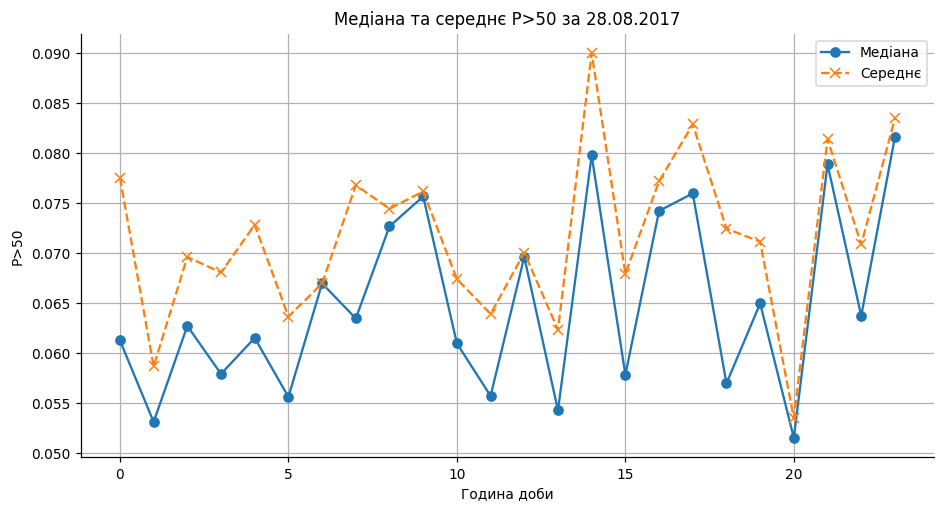

In [15]:
day_data = A.reset_index()

day_data = day_data[
    (day_data['ts'] >= '2017-08-28') &
    (day_data['ts'] < '2017-08-29')
]

hour_stats = day_data.groupby(
    day_data['ts'].dt.hour
)['P>50'].agg(['median', 'mean'])

print(hour_stats)
plt.figure(figsize=(10, 5))

plt.plot(
    hour_stats.index,
    hour_stats['median'],
    marker='o',
    linestyle='-',
    label='Медіана'
)

plt.plot(
    hour_stats.index,
    hour_stats['mean'],
    marker='x',
    linestyle='--',
    label='Середнє'
)

plt.xlabel('Година доби')
plt.ylabel('P>50')
plt.title('Медіана та середнє P>50 за 28.08.2017')
plt.legend()
plt.grid()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)* на даному прикладі лінії накладаються (однаковий результат для двох метрик). Відмінність між ними була б суттєвою за наявності викидів, бо медіана менш чутлива до таких значень

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
C_h = C[['ts', 'speed', 'density']].copy()

B_h = B.copy()
B_h['date'] = B_h['ts'].dt.date

B_h = B_h.loc[B_h.index.repeat(24)].copy()

B_h['hour'] = B_h.groupby('date').cumcount()

B_h['ts'] = pd.to_datetime(B_h['date'].astype(str) + ' ' +
    B_h['hour'].astype(str) + ':00:00')

B_h = B_h[['ts', 'F10.7']]

A_h = A_h.reset_index()

A_h.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in A_h.columns
]
A_h = A_h[
    ['ts',
     'P>1_mean', 'P>1_max',
     'P>5_mean', 'P>5_max',
     'P>10_mean', 'P>10_max',
     'P>30_mean', 'P>30_max',
     'P>50_mean', 'P>50_max',
     'P>100_mean', 'P>100_max',
     'E>0.8_mean', 'E>0.8_max',
     'E>2.0_mean', 'E>2.0_max']
]

M_inner = A_h.merge(B_h, on='ts', how='inner')
M_inner = M_inner.merge(C_h, on='ts', how='inner')
M = M_inner.sort_values('ts').reset_index(drop=True)

print(M.shape)
display(M[M.isna().any(axis=1)])
M_outer = A_h.merge(B_h, on='ts', how='outer')
M_outer = M_outer.merge(C_h, on='ts', how='outer')

print('inner:', len(M_inner))
print('outer:', len(M_outer))

(600, 20)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,F10.7,speed,density
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,140,NaN,NaN
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,140,NaN,NaN
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,140,NaN,NaN
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,140,NaN,NaN
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,140,NaN,NaN
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,140,NaN,NaN
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,140,NaN,NaN
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,140,NaN,NaN


inner: 600
outer: 601


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)* inner: 600, outer: 2932. Зумовлено тим, що outer зберігає всі часові точки

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
def group(x):
    if pd.isna(x):
        return np.nan
    elif x < 10:
        return 'тиха'
    elif x < 1000:
        return 'активна'
    else:
        return 'дуже активна'


M['група'] = M['P>10_max'].apply(group)

print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 7.44385701010101
Медіана: 0.08024583333333334


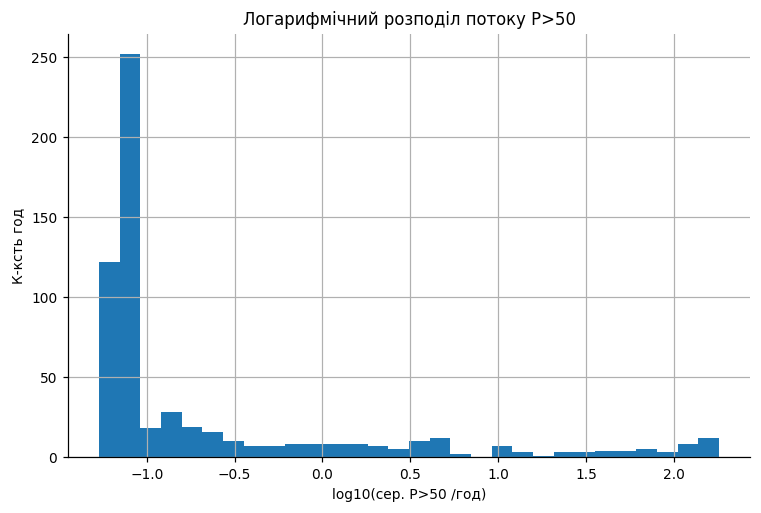

In [19]:

values = M['P>50_mean'].dropna()
print('Середнє:', values.mean())
print('Медіана:', values.median())

plt.figure(figsize=(8, 5))

plt.hist(np.log10(values[values > 0]), bins=30)

plt.xlabel('log10(сер. P>50 /год)')
plt.ylabel('К-ксть год')
plt.title('Логарифмічний розподіл потоку P>50')

plt.grid()
plt.show()

**Висновок:** Дані мають великий стрибок, тобто різниця між мінімальним та максимальним значенням сягає 100+. Звідси середнє значення залежить від більших, а медіана лишається низькою через малі значення, яких значно більше.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

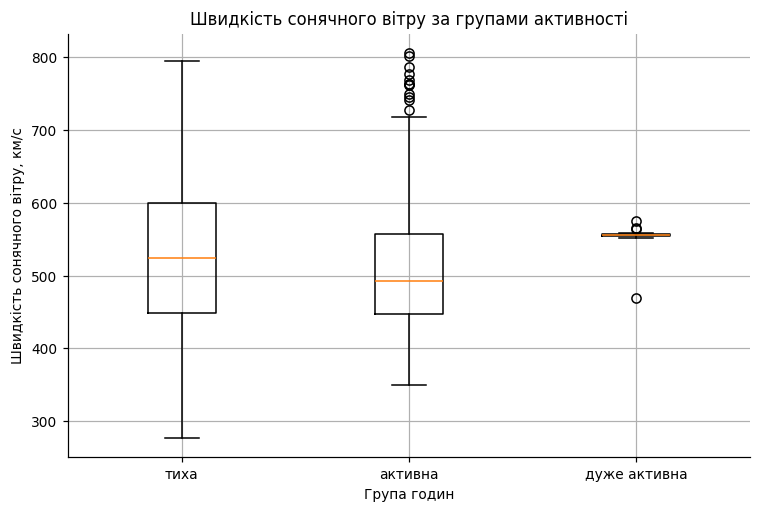

In [20]:
groups = [
    M[M['група'] == 'тиха']['speed'].dropna(),
    M[M['група'] == 'активна']['speed'].dropna(),
    M[M['група'] == 'дуже активна']['speed'].dropna()
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    groups,
    tick_labels=['тиха', 'активна', 'дуже активна']
)

plt.xlabel('Група годин')
plt.ylabel('Швидкість сонячного вітру, км/с')
plt.title('Швидкість сонячного вітру за групами активності')

plt.grid()
plt.show()

**Висновок:** Медіанні значення трьох груп годин варіюються в межах 500-600 км/год, однак в активній та дуже активній групах більший діапазон, а в тихій групі є значення-викиди, які набувають 700+ км/с.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

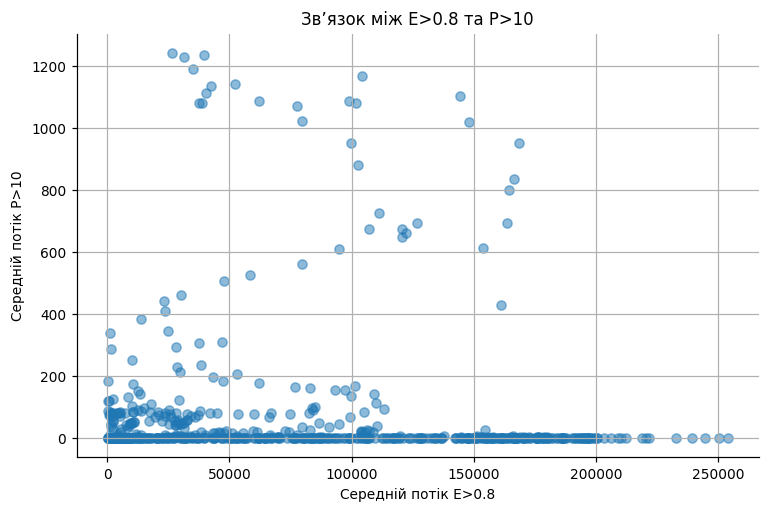

Коеф. кореляції: -0.049458779778013884


In [21]:
data = M[['E>0.8_mean', 'P>10_mean']].dropna()

correlation = data['E>0.8_mean'].corr(data['P>10_mean'])

plt.figure(figsize=(8, 5))

plt.scatter(
    data['E>0.8_mean'],
    data['P>10_mean'],
    alpha=0.5
)

plt.xlabel('Середній потік E>0.8')
plt.ylabel('Середній потік P>10')
plt.title('Зв’язок між E>0.8 та P>10')

plt.grid()
plt.show()

print('Коеф. кореляції:', correlation)

**Висновок:** Коеф. кореляції є доволі низьким, що свідчить про низький лінійний звʼязок між даними. Також це можна побачити на графіку: певні значення розкидані, що відображає звʼязок між ними. Присутні аномальні значення

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

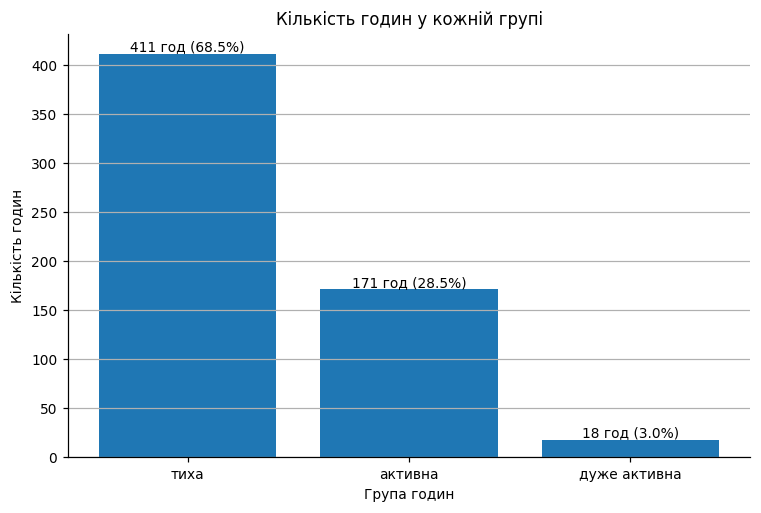

In [22]:
counts = M['група'].value_counts().reindex(
    ['тиха', 'активна', 'дуже активна']
)

percent = counts / counts.sum() * 100

plt.figure(figsize=(8, 5))

bars = plt.bar(counts.index, counts.values)

plt.xlabel('Група годин')
plt.ylabel('Кількість годин')
plt.title('Кількість годин у кожній групі')

for bar, count, pct in zip(bars, counts, percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} год ({pct:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y')
plt.show()

**Висновок:** Більшість спостережувальних годин міститься у тихій групі годин (263), активна група годин налічує 199 год, а дуже активна є порівняно меншою - всього 32 години.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

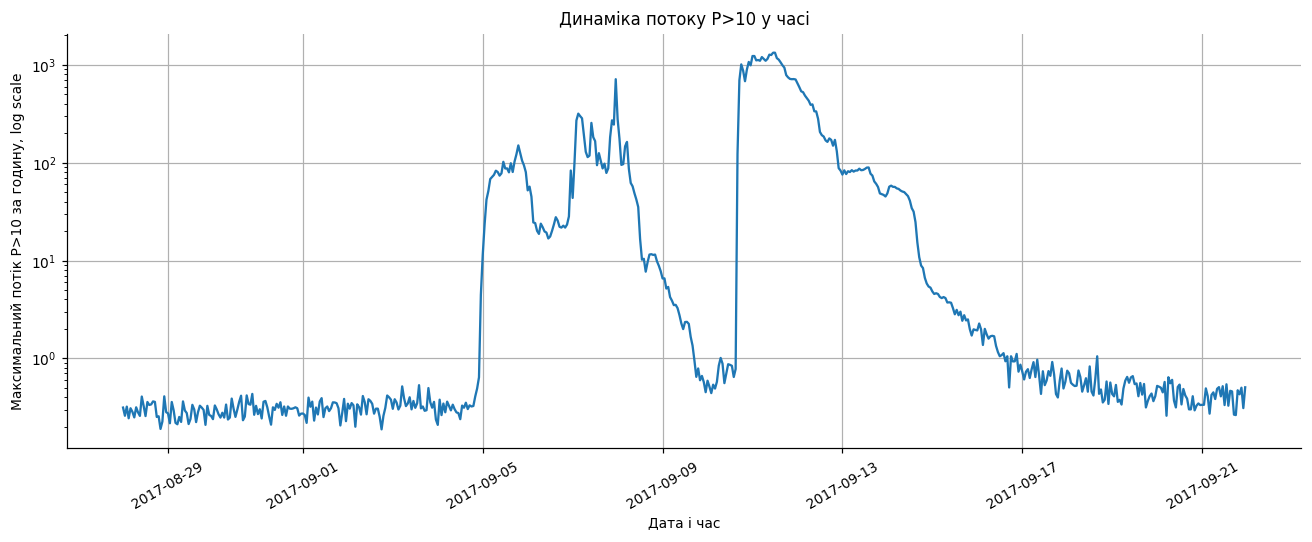

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    M['ts'],
    M['P>10_max']
)

plt.yscale('log')

plt.xlabel('Дата і час')
plt.ylabel('Максимальний потік P>10 за годину, log scale')
plt.title('Динаміка потоку P>10 у часі')

plt.xticks(rotation=30)
plt.grid()
plt.tight_layout()

plt.show()

**Висновок:** Протягом половини періоду максимальні погодинні значення P>10 залишаються невисокими, але спостерігаються  різкі піки, найвищий з яких становить 1330

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

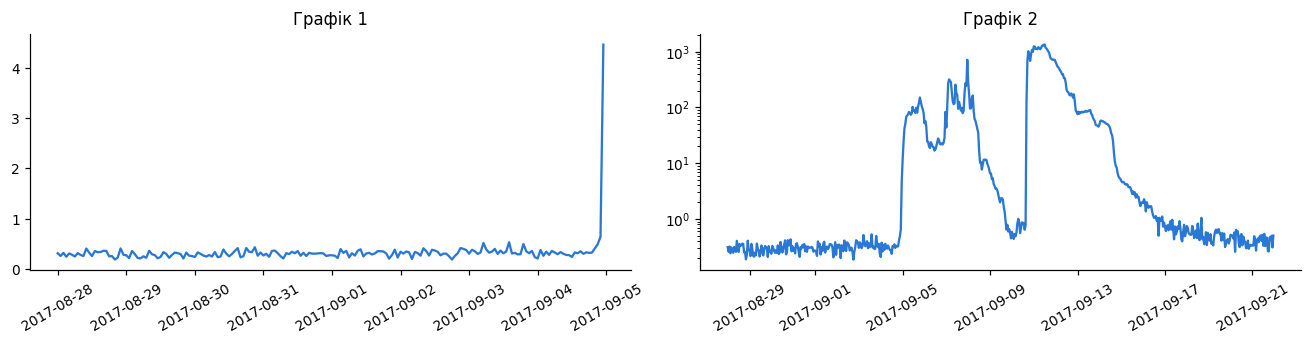

In [24]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: коливання максимального значення є невеликми, тому великі піки майже не помітні на звичайній лінійній шкалі. Під кінець стрімко зростає
2. Висновок з другого графіка: Протягом половини періоду максимальні погодинні значення P>10 залишаються невисокими, але спостерігаються різкі піки. Логарифмічна шкала дозволяє одночасно побачити і звичайні значення, і великі піки.
3. Дві відмінності між ними: графіки показують різні періоди: перший охопив 28.08.2017-05.09.2017, другйи -  весь період спостережень.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

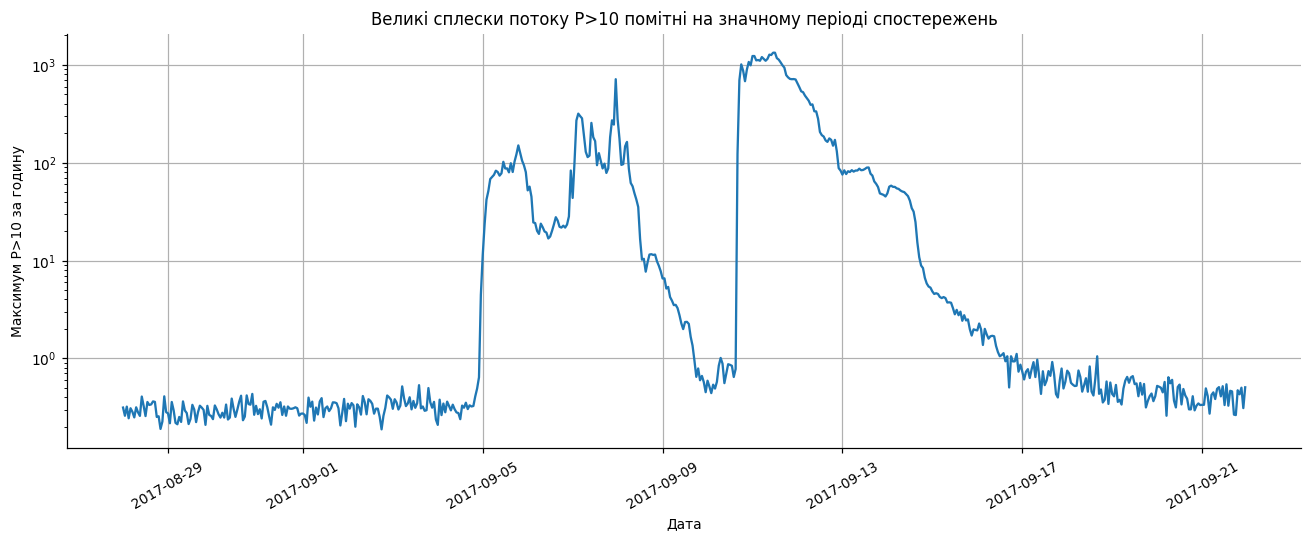

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(M['ts'], M['P>10_max'])

plt.yscale('log')

plt.xlabel('Дата')
plt.ylabel('Максимум P>10 за годину')
plt.title('Великі сплески потоку P>10 помітні на значному періоді спостережень')

plt.xticks(rotation=30)
plt.grid(True)

plt.tight_layout()
plt.show()


**Відповідь 6.2:** *(чому ви побудували графік саме так)* Даний графік дає змогу одночасно побачити звичайні значення потоку та великі сплески, тим самим відобража.чи реальний зміст спостережень


---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** значення потоку P>10 мають дуже великий розкид. Максимальне значення становить 1330, тоді як більшість  значень значно менші (до 0.35). Див. етап 6

**Спостереження 2:** Більшість спостережувальних годин міститься у тихій групі годин (263), а дуже активна є порівняно меншою - всього 32 години. Див. етап 5, графік 4.

**Спостереження 3:** Зв’язок між E>0.8 та P>10 є двоволі низьким (0.37), тим самим дані не створюють чіткої висхідної/низхідної лінії.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
#У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?
day = B.loc[B['F10.7'].idxmax(), 'ts']
max_f107 = B['F10.7'].max()

day_p50 = A['P>50'].idxmax()
max_p50 = A['P>50'].max()

print('Максимальний F10.7:')
print('Дата:', day)
print('Значення:', max_f107)

print('\nМаксимальний P>50:')
print('Дата:', day_p50)
print('Значення:', max_p50)

print('\nЧи збігаються дні:', day.date() == day_p50.date())

Максимальний F10.7:
Дата: 2017-09-04 00:00:00
Значення: 140

Максимальний P>50:
Дата: 2017-09-10 22:20:00
Значення: 191.0

Чи збігаються дні: False


**Відповідь 7.2:** Найбільший радіопотік був 4.9.2017 та він не збігається з моїм потоком, оскільки P>50 набуло максимального значення 10.9.2017

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'ні',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Етап 3: перевірка правильності написання ф-цій. Також виникли проблеми під час форматування часу. Етап 4: допомога злити три таблиці в одну. Графіки: побудова гарніших графіків та/або виправлення помилок під час будови'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Ляшко Леся
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    ні
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
Етап 3: перевірка правильності написання ф-цій. Також виникли проблеми під час форматування часу. Етап 4: допомога злити три таблиці в одну. Графіки: побудова гарніших графіків та/або виправлення помилок під час будови
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
